# Home Credit Default Risk - Exploration & Préparation des données

**Objectif** : identifier les clients capables de rembourser leur crédit (TARGET = 0) de ceux qui ne le pourront pas (TARGET = 1).

Ce notebook couvre :
1. Exploration des données (EDA)
2. Détection et traitement des anomalies
3. Nettoyage et encodage
4. Feature engineering métier

## 1. Imports

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings

from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
plt.style.use('fivethirtyeight')

## 2. Chargement des données

In [63]:
app_train = pd.read_csv('data/application_train.csv')
app_test  = pd.read_csv('data/application_test.csv')

print('Train :', app_train.shape)
print('Test  :', app_test.shape)
app_train.head()

Train : (307511, 122)
Test  : (48744, 121)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [64]:
# Vérification des doublons
train_dups = app_train.duplicated().sum()
test_dups  = app_test.duplicated().sum()
print(f'Doublons dans train : {train_dups}')
print(f'Doublons dans test  : {test_dups}')

if train_dups > 0:
    app_train = app_train.drop_duplicates()
    print(f'Doublons supprimés dans train.')
if test_dups > 0:
    app_test = app_test.drop_duplicates()
    print(f'Doublons supprimés dans test.')

Doublons dans train : 0
Doublons dans test  : 0


## 3. Exploration des données (EDA)

### 3.1 Distribution de la variable cible

- **TARGET = 0** : le client a remboursé son crédit
- **TARGET = 1** : le client a eu des difficultés à rembourser

TARGET
0    282686
1     24825
Name: count, dtype: int64

Taux de défaut : 8.07%


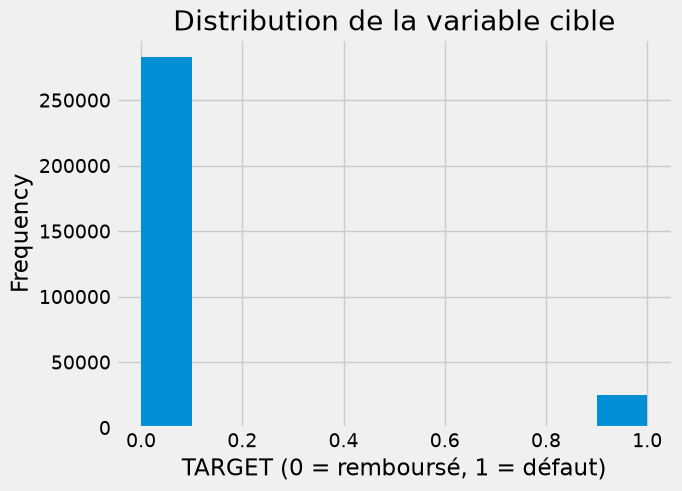

In [65]:
print(app_train['TARGET'].value_counts())
print('\nTaux de défaut : {:.2f}%'.format(100 * app_train['TARGET'].mean()))

app_train['TARGET'].astype(int).plot.hist(title='Distribution de la variable cible');
plt.xlabel('TARGET (0 = remboursé, 1 = défaut)');

> **Déséquilibre de classes** : les défauts sont minoritaires (~8%). Il faudra en tenir compte lors de l'entraînement du modèle.

### 3.2 Valeurs manquantes

In [66]:
def missing_values_table(df):
    mis_val = df.isnull().sum()
    mis_val_percent = 100 * mis_val / len(df)
    table = pd.concat([mis_val, mis_val_percent], axis=1)
    table.columns = ['Valeurs manquantes', '% du total']
    table = table[table['% du total'] > 0].sort_values('% du total', ascending=False).round(1)
    print(f'{df.shape[1]} colonnes au total, {table.shape[0]} ont des valeurs manquantes.')
    return table

missing_values_table(app_train).head(20)

122 colonnes au total, 67 ont des valeurs manquantes.


,Valeurs manquantes,% du total
COMMONAREA_MEDI,214865,69.9
COMMONAREA_MODE,214865,69.9
COMMONAREA_AVG,214865,69.9
NONLIVINGAPARTMENTS_MODE,213514,69.4
NONLIVINGAPARTMENTS_MEDI,213514,69.4
NONLIVINGAPARTMENTS_AVG,213514,69.4
FONDKAPREMONT_MODE,210295,68.4
LIVINGAPARTMENTS_AVG,210199,68.4
LIVINGAPARTMENTS_MEDI,210199,68.4
LIVINGAPARTMENTS_MODE,210199,68.4


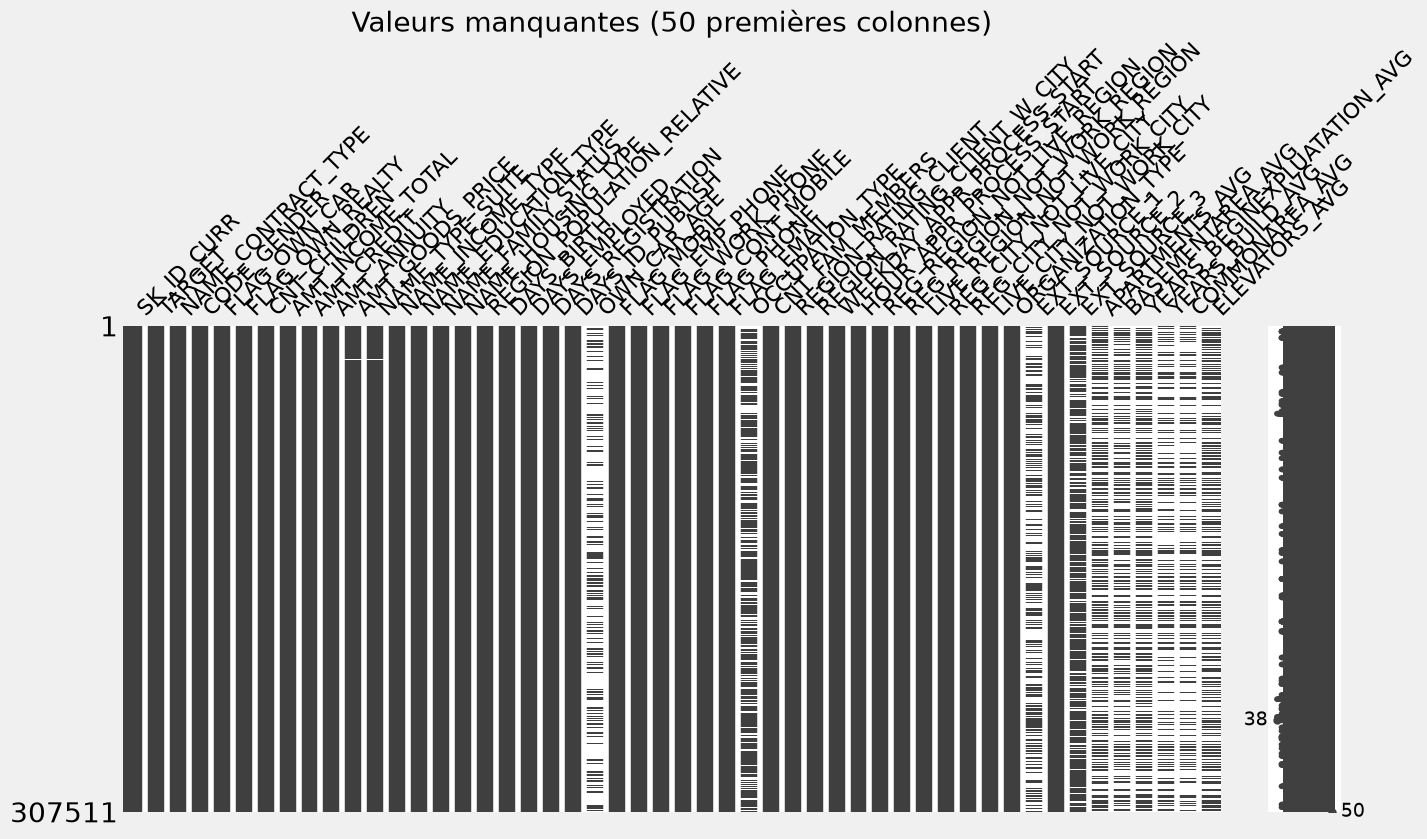

In [67]:
# Visualisation des valeurs manquantes avec missingno
msno.matrix(app_train.iloc[:, :50], figsize=(14, 6));
plt.title('Valeurs manquantes (50 premières colonnes)');

### 3.3 Types de colonnes

In [68]:
print('Types de colonnes :')
print(app_train.dtypes.value_counts())

print('\nNombre de catégories par colonne catégorielle :')
print(app_train.select_dtypes('object').apply(pd.Series.nunique, axis=0))

Types de colonnes :
float64    65
int64      41
str        16
Name: count, dtype: int64

Nombre de catégories par colonne catégorielle :
NAME_CONTRACT_TYPE             2
CODE_GENDER                    3
FLAG_OWN_CAR                   2
FLAG_OWN_REALTY                2
NAME_TYPE_SUITE                7
NAME_INCOME_TYPE               8
NAME_EDUCATION_TYPE            5
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
OCCUPATION_TYPE               18
WEEKDAY_APPR_PROCESS_START     7
ORGANIZATION_TYPE             58
FONDKAPREMONT_MODE             4
HOUSETYPE_MODE                 3
WALLSMATERIAL_MODE             7
EMERGENCYSTATE_MODE            2
dtype: int64


### 3.4 Corrélations avec la variable cible

In [69]:
correlations = app_train.select_dtypes(include=[np.number]).corr()['TARGET'].sort_values()

print('Corrélations les plus négatives (protecteurs contre le défaut) :')
print(correlations.head(15))
print('\nCorrélations les plus positives (facteurs de risque) :')
print(correlations.tail(15))

Corrélations les plus négatives (protecteurs contre le défaut) :
EXT_SOURCE_3                 -0.178919
EXT_SOURCE_2                 -0.160472
EXT_SOURCE_1                 -0.155317
DAYS_EMPLOYED                -0.044932
FLOORSMAX_AVG                -0.044003
FLOORSMAX_MEDI               -0.043768
FLOORSMAX_MODE               -0.043226
AMT_GOODS_PRICE              -0.039645
REGION_POPULATION_RELATIVE   -0.037227
ELEVATORS_AVG                -0.034199
ELEVATORS_MEDI               -0.033863
FLOORSMIN_AVG                -0.033614
FLOORSMIN_MEDI               -0.033394
LIVINGAREA_AVG               -0.032997
LIVINGAREA_MEDI              -0.032739
Name: TARGET, dtype: float64

Corrélations les plus positives (facteurs de risque) :
DEF_60_CNT_SOCIAL_CIRCLE       0.031276
DEF_30_CNT_SOCIAL_CIRCLE       0.032248
LIVE_CITY_NOT_WORK_CITY        0.032518
OWN_CAR_AGE                    0.037612
DAYS_REGISTRATION              0.041975
FLAG_DOCUMENT_3                0.044346
REG_CITY_NOT_LIVE_CITY   

### 3.5 Effet de l'âge sur le remboursement

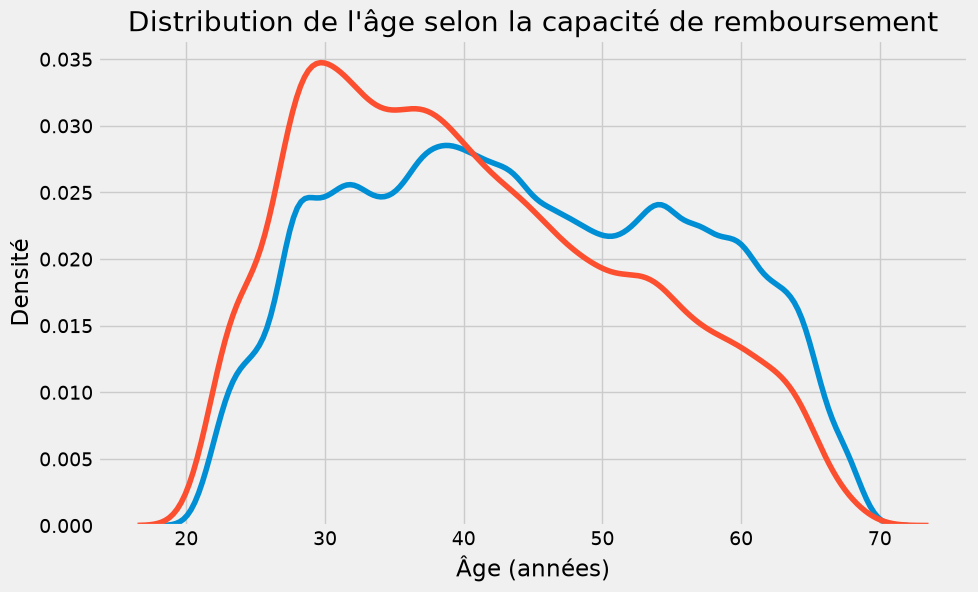

In [70]:
# DAYS_BIRTH est en jours négatifs → on prend la valeur absolue et on convertit en années
age_data = app_train[['TARGET', 'DAYS_BIRTH']].copy()
age_data['AGE'] = abs(age_data['DAYS_BIRTH']) / 365

plt.figure(figsize=(10, 6))
sns.kdeplot(age_data.loc[age_data['TARGET'] == 0, 'AGE'], label='Remboursé (TARGET=0)')
sns.kdeplot(age_data.loc[age_data['TARGET'] == 1, 'AGE'], label='Défaut (TARGET=1)')
plt.xlabel('Âge (années)'); plt.ylabel('Densité')
plt.title('Distribution de l\'âge selon la capacité de remboursement');

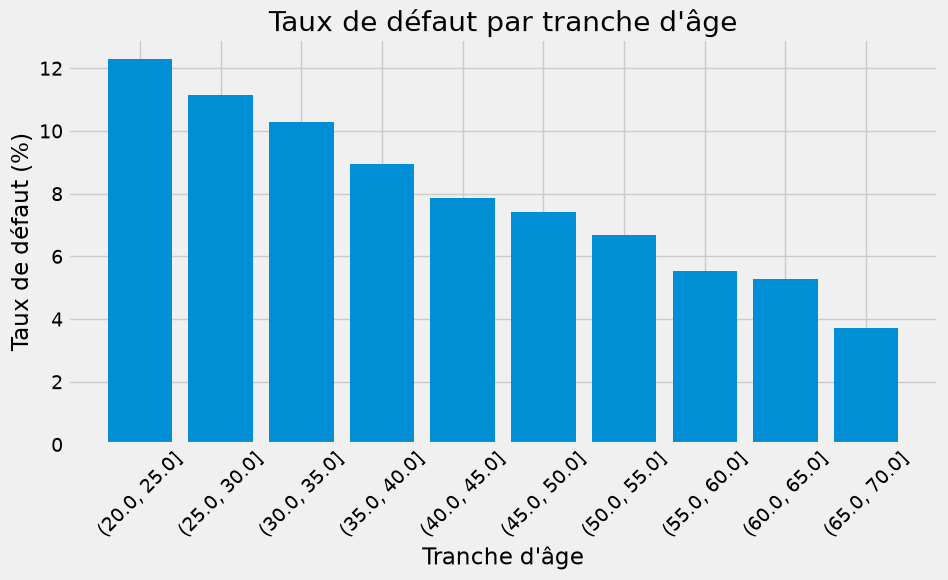

In [71]:
# Taux de défaut par tranche d'âge
age_data['AGE_BINNED'] = pd.cut(age_data['AGE'], bins=np.linspace(20, 70, num=11))
age_groups = age_data.groupby('AGE_BINNED')['TARGET'].mean()

plt.figure(figsize=(10, 5))
plt.bar(age_groups.index.astype(str), 100 * age_groups)
plt.xticks(rotation=45); plt.xlabel('Tranche d\'âge'); plt.ylabel('Taux de défaut (%)')
plt.title('Taux de défaut par tranche d\'âge');

### 3.6 Sources externes (EXT_SOURCE)

Ces 3 variables sont les plus corrélées négativement avec le défaut : plus le score est élevé, plus le client est fiable.

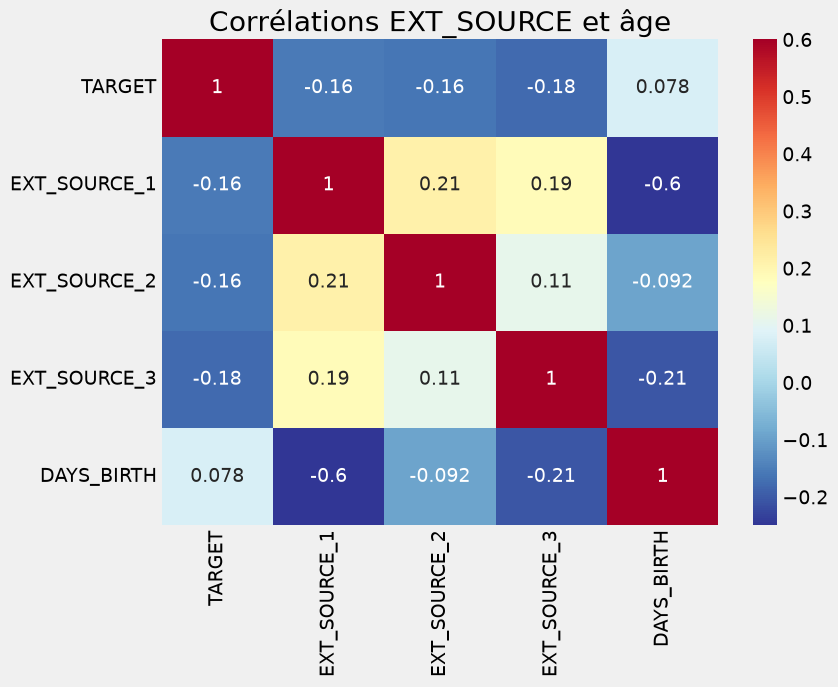

In [72]:
ext_data = app_train[['TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']]

plt.figure(figsize=(8, 6))
sns.heatmap(ext_data.corr(), cmap='RdYlBu_r', vmin=-0.25, annot=True, vmax=0.6)
plt.title('Corrélations EXT_SOURCE et âge');

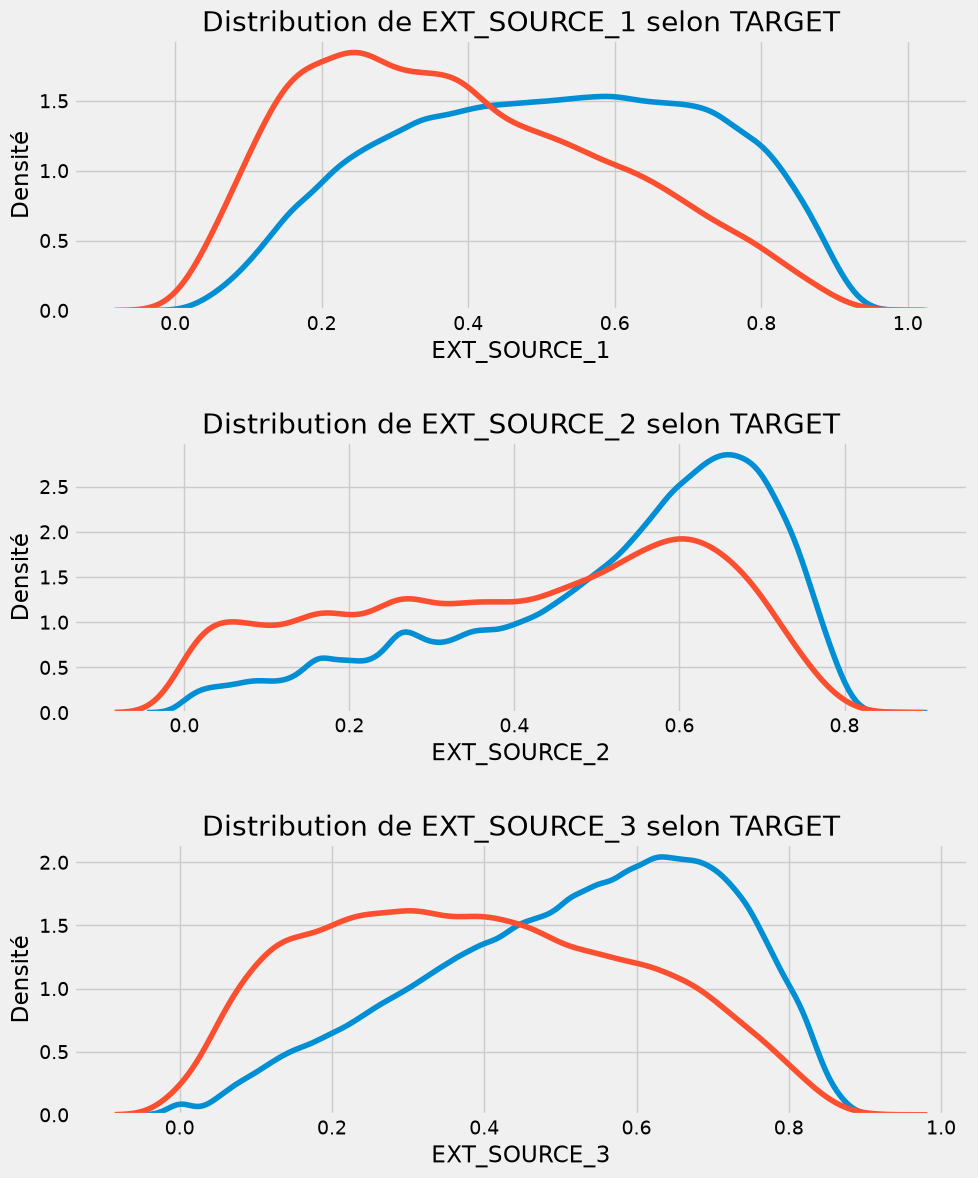

In [73]:
plt.figure(figsize=(10, 12))
for i, source in enumerate(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    plt.subplot(3, 1, i + 1)
    sns.kdeplot(app_train.loc[app_train['TARGET'] == 0, source], label='Remboursé')
    sns.kdeplot(app_train.loc[app_train['TARGET'] == 1, source], label='Défaut')
    plt.title(f'Distribution de {source} selon TARGET')
    plt.xlabel(source); plt.ylabel('Densité')
plt.tight_layout(h_pad=2.5);

## 4. Nettoyage des données

### 4.1 Anomalie DAYS_EMPLOYED

Certains clients ont une valeur de 365 243 jours (~1000 ans), ce qui est une erreur de saisie. On les remplace par NaN et on crée un flag pour signaler ces cas au modèle.

In [74]:
print('Statistiques DAYS_EMPLOYED avant nettoyage :')
print(app_train['DAYS_EMPLOYED'].describe())

anom = app_train[app_train['DAYS_EMPLOYED'] == 365243]
non_anom = app_train[app_train['DAYS_EMPLOYED'] != 365243]
print(f'\nTaux de défaut (normaux) : {100 * non_anom["TARGET"].mean():.2f}%')
print(f'Taux de défaut (anomalies) : {100 * anom["TARGET"].mean():.2f}%')
print(f'Nombre d\'anomalies : {len(anom)}')

Statistiques DAYS_EMPLOYED avant nettoyage :
count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

Taux de défaut (normaux) : 8.66%
Taux de défaut (anomalies) : 5.40%
Nombre d'anomalies : 55374


In [75]:
# Flaguer et remplacer les anomalies
for df in [app_train, app_test]:
    df['DAYS_EMPLOYED_ANOM'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)
    df['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)

print('Train - anomalies traitées :', app_train['DAYS_EMPLOYED_ANOM'].sum())
print('Test  - anomalies traitées :', app_test['DAYS_EMPLOYED_ANOM'].sum())

Train - anomalies traitées : 55374
Test  - anomalies traitées : 9274


### 4.2 Encodage des variables catégorielles

- **LabelEncoder** : pour les colonnes avec exactement 2 catégories
- **One-Hot Encoding** : pour les colonnes avec plus de 2 catégories

In [76]:
education_order = {
    'Lower secondary'               : 0,
    'Secondary / secondary special' : 1,
    'Incomplete higher'             : 2,
    'Higher education'              : 3,
    'Academic degree'               : 4,
}

for df in [app_train, app_test]:
    df['NAME_EDUCATION_TYPE'] = df['NAME_EDUCATION_TYPE'].map(education_order)

print('Encodage ordinal NAME_EDUCATION_TYPE :')
print(app_train['NAME_EDUCATION_TYPE'].value_counts().sort_index())

Encodage ordinal NAME_EDUCATION_TYPE :
NAME_EDUCATION_TYPE
0      3816
1    218391
2     10277
3     74863
4       164
Name: count, dtype: int64


### 4.2 Encodage ordinal de NAME_EDUCATION_TYPE

Cette variable a un ordre naturel clair : plus le niveau d'éducation est élevé, plus le client est potentiellement solvable. On lui assigne un entier ordonné plutôt que de la passer en one-hot encoding.

In [77]:
le = LabelEncoder()
le_count = 0

for col in app_train:
    if app_train[col].dtype == 'object':
        if app_train[col].nunique() <= 2:
            le.fit(app_train[col])
            app_train[col] = le.transform(app_train[col])
            app_test[col]  = le.transform(app_test[col])
            le_count += 1

print(f'{le_count} colonnes encodées avec LabelEncoder.')

app_train = pd.get_dummies(app_train)
app_test  = pd.get_dummies(app_test)

print('Train après encodage :', app_train.shape)
print('Test  après encodage :', app_test.shape)

0 colonnes encodées avec LabelEncoder.
Train après encodage : (307511, 243)
Test  après encodage : (48744, 239)


### 4.3 Alignement train / test

On s'assure que les deux datasets ont les mêmes colonnes après le one-hot encoding.

In [78]:
train_labels = app_train['TARGET']

app_train, app_test = app_train.align(app_test, join='inner', axis=1)
app_train['TARGET'] = train_labels

print('Train final :', app_train.shape)
print('Test  final :', app_test.shape)

Train final : (307511, 240)
Test  final : (48744, 239)


### 4.4 Traitement des valeurs manquantes

Stratégie en deux étapes :
- **Supprimer** les colonnes avec plus de 50% de NaN (colonnes logement) - imputer 70% de valeurs reviendrait à inventer des données
- **Imputer par la médiane** les colonnes avec moins de 50% de NaN (EXT_SOURCE, AMT_REQ_CREDIT_BUREAU...)

In [79]:
from sklearn.impute import SimpleImputer

# Étape 1 : supprimer les colonnes avec plus de 50% de NaN
threshold = 0.5
missing_rate = app_train.isnull().mean()
cols_to_drop = missing_rate[missing_rate > threshold].index.tolist()
cols_to_drop = [c for c in cols_to_drop if c != 'TARGET']

app_train.drop(columns=cols_to_drop, inplace=True)
app_test.drop(columns=[c for c in cols_to_drop if c in app_test.columns], inplace=True)

print(f'{len(cols_to_drop)} colonnes supprimées (>{int(threshold*100)}% de NaN)')
print('Colonnes supprimées :', cols_to_drop)

# Étape 2 : imputer les NaN restants par la médiane
target_col = app_train['TARGET']
num_cols = app_train.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != 'TARGET']

imputer = SimpleImputer(strategy='median')
app_train[num_cols] = imputer.fit_transform(app_train[num_cols])
app_test[num_cols]  = imputer.transform(app_test[num_cols])

app_train['TARGET'] = target_col

print(f'\nNaN restants dans train : {app_train.isnull().sum().sum()}')
print(f'NaN restants dans test  : {app_test.isnull().sum().sum()}')
print(f'\nDimensions finales - Train : {app_train.shape} | Test : {app_test.shape}')

38 colonnes supprimées (>50% de NaN)
Colonnes supprimées : ['OWN_CAR_AGE', 'EXT_SOURCE_1', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI']

NaN restants dans train : 0
NaN restants dans test  : 0

Dimensions finales - Train : (307511, 202) | Test : (48744, 201)


## 5. Feature Engineering métier

Ces ratios capturent des notions financières clés pour évaluer la solvabilité d'un client.

In [80]:
for df in [app_train, app_test]:
    # Part du crédit par rapport aux revenus
    df['CREDIT_INCOME_PERC']    = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']
    # Part de l'annuité par rapport aux revenus (charge mensuelle)
    df['ANNUITY_INCOME_PERC']   = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
    # Durée du crédit en mois
    df['CREDIT_TERM']           = df['AMT_ANNUITY'] / df['AMT_CREDIT']
    # Ancienneté dans l'emploi relative à l'âge
    df['DAYS_EMPLOYED_PERC']    = df['DAYS_EMPLOYED'] / df['DAYS_BIRTH']

print('Features métier ajoutées.')
app_train[['CREDIT_INCOME_PERC', 'ANNUITY_INCOME_PERC', 'CREDIT_TERM', 'DAYS_EMPLOYED_PERC']].describe()

Features métier ajoutées.


,CREDIT_INCOME_PERC,ANNUITY_INCOME_PERC,CREDIT_TERM,DAYS_EMPLOYED_PERC
count,307511.000000,307511.000000,307511.000000,307511.000000
mean,3.957570,0.180929,0.053695,-2.920135
std,2.689728,0.094573,0.022482,6.627098
min,0.004808,0.000224,0.016790,-47.489663
25%,2.018667,0.114782,0.036900,0.021559
50%,3.265067,0.162833,0.050000,0.088645
75%,5.159880,0.229067,0.064043,0.191000
max,84.736842,1.875965,0.158114,0.728811


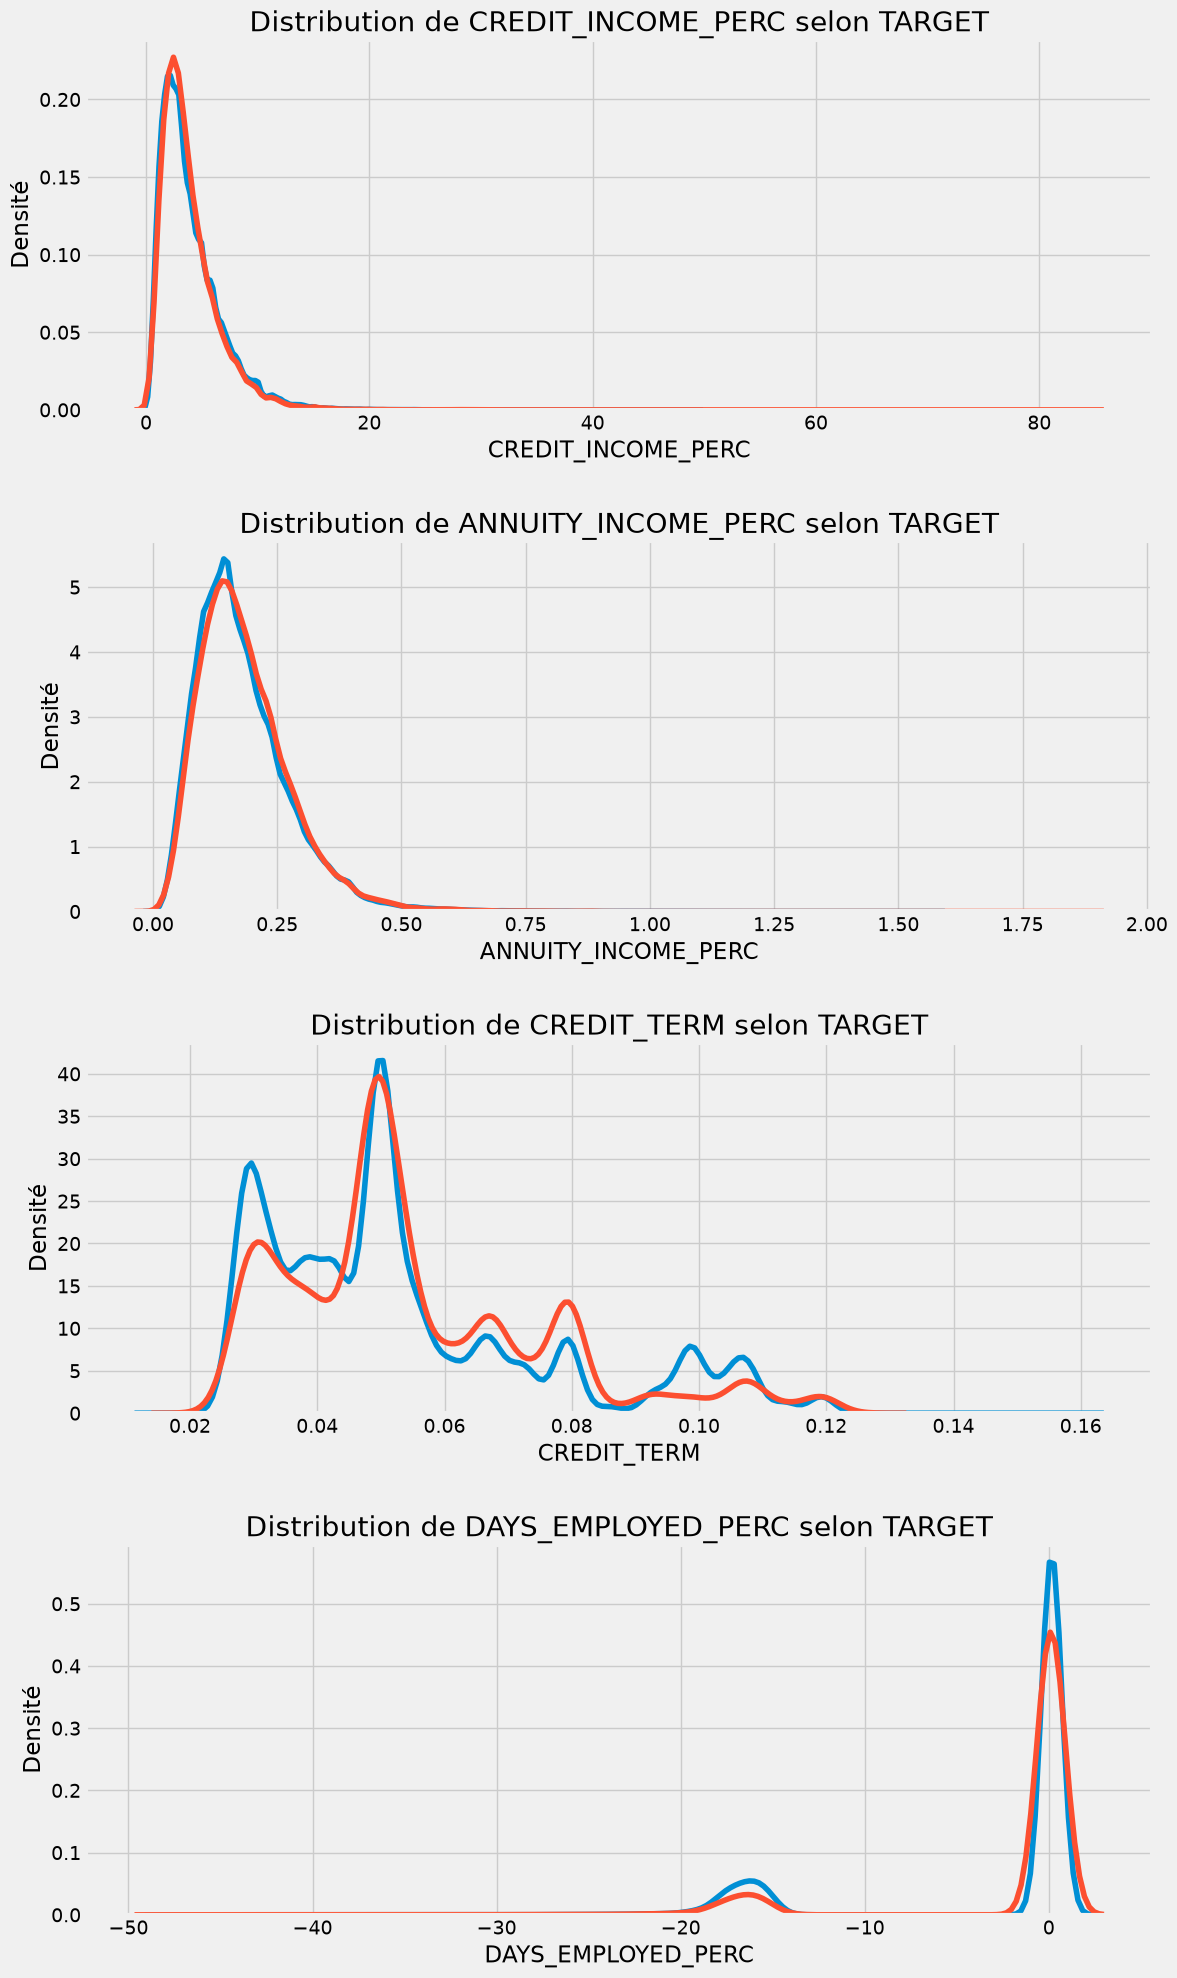

In [81]:
# Visualisation des nouvelles features par rapport à la cible
plt.figure(figsize=(12, 20))
for i, feature in enumerate(['CREDIT_INCOME_PERC', 'ANNUITY_INCOME_PERC', 'CREDIT_TERM', 'DAYS_EMPLOYED_PERC']):
    plt.subplot(4, 1, i + 1)
    sns.kdeplot(app_train.loc[app_train['TARGET'] == 0, feature], label='Remboursé')
    sns.kdeplot(app_train.loc[app_train['TARGET'] == 1, feature], label='Défaut')
    plt.title(f'Distribution de {feature} selon TARGET')
    plt.xlabel(feature); plt.ylabel('Densité')
plt.tight_layout(h_pad=2.5);

## 6. Export des données préparées

On sauvegarde les datasets nettoyés pour les utiliser dans le notebook de modélisation.

In [82]:
app_train.to_csv('data/app_train_clean.csv', index=False)
app_test.to_csv('data/app_test_clean.csv', index=False)

print('Données exportées :')
print(f'  data/app_train_clean.csv : {app_train.shape}')
print(f'  data/app_test_clean.csv  : {app_test.shape}')

Données exportées :
  data/app_train_clean.csv : (307511, 206)
  data/app_test_clean.csv  : (48744, 205)
